# 🎬 Deepfake Video Detection — TensorFlow/Keras




## 1. Installation

In [1]:
!pip install -q tensorflow opencv-python-headless facenet-pytorch \
             scikit-learn matplotlib seaborn tqdm albumentations kaggle

import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                         '--format=csv,noheader'], capture_output=True, text=True)
print('GPU:', result.stdout.strip() if result.returncode == 0 else 'CPU only')

GPU: Tesla T4, 15360 MiB


## 2. Imports

In [3]:
import os, re, json, time, random, warnings, shutil
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import cv2
import PIL.Image as Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.mixed_precision import set_global_policy

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
import pandas as pd

try:
    from facenet_pytorch import MTCNN
    import torch
    MTCNN_AVAILABLE = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'facenet-pytorch'])
    from facenet_pytorch import MTCNN
    import torch
    MTCNN_AVAILABLE = True

SEED = 42

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'🔧 GPU(s) available: {len(gpus)}')
else:
    print('🔧 CPU mode')

print(f'🐍 TensorFlow: {tf.__version__}')
print(f'🐍 Keras: {keras.__version__}')

🔧 GPU(s) available: 1
🐍 TensorFlow: 2.19.0
🐍 Keras: 3.13.2


## 3. Configuration

In [ ]:
@dataclass
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    DATA_ROOT:        str   = '/content/deep-fake-detection/Celeb-DF'
    PROCESSED_DIR:    str   = '/content/deep-fake-detection/working/processed'
    MODEL_DIR:        str   = '/content/deep-fake-detection/working/models'
    LOG_DIR:          str   = '/content/deep-fake-detection/working/logs'

    # ── Video sampling ────────────────────────────────────────────────────────
    NUM_FRAMES:       int   = 16
    FRAME_SIZE:       int   = 224
    FACE_MARGIN:      float = 0.3
    VIDEO_EXTENSIONS: tuple = ('.mp4', '.avi', '.mov', '.mkv')

    # ── Model architecture ────────────────────────────────────────────────────
    CNN_FEAT_DIM:     int   = 2048
    LSTM_HIDDEN:      int   = 512
    LSTM_LAYERS:      int   = 2
    #  Reduced LSTM dropout from 0.4 → 0.2 (was too high, caused gradient starvation)
    LSTM_DROPOUT:     float = 0.2
    FC_DROPOUT:       float = 0.5

    # ── Training ──────────────────────────────────────────────────────────────
    EPOCHS:           int   = 30
    BATCH_SIZE:       int   = 8
    LR:               float = 1e-4
    LR_CNN:           float = 1e-5
    WEIGHT_DECAY:     float = 1e-4
    WARMUP_EPOCHS:    int   = 3
    #  Reduced label smoothing 0.1 → 0.05 (0.1 kills signal on imbalanced data)
    LABEL_SMOOTHING:  float = 0.05
    GRAD_CLIP:        float = 1.0
    MIXED_PRECISION:  bool  = True
    EARLY_STOP:       int   = 10
    VAL_SPLIT:        float = 0.15
    TEST_SPLIT:       float = 0.10
    #  Unfreeze from layer 100 (was 143 = 82% frozen). More backbone is trainable.
    CNN_FREEZE_UNTIL: int   = 100
    #  Explicit focal loss option to fight class imbalance
    USE_FOCAL_LOSS:   bool  = True
    FOCAL_GAMMA:      float = 2.0

    # ── Augmentation ──────────────────────────────────────────────────────────
    USE_AUGMENT:      bool  = True
    FLIP_P:           float = 0.5
    BRIGHTNESS:       float = 0.2
    CONTRAST:         float = 0.2

    def __post_init__(self):
        for d in [self.PROCESSED_DIR, self.MODEL_DIR, self.LOG_DIR]:
            Path(d).mkdir(parents=True, exist_ok=True)

CFG = Config()


set_global_policy('float32')
print('✅ float32 precision')

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

print('✅ configs saved success')

✅ float32 precision
✅ configs saved success


## 4. Data Download (Celeb-DF)

In [5]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"elboumashouliachraf","key":"4f57f35dae4ea2a8f6bda5ca6d712b35"}'}

In [6]:
!mkdir -p ~/.config/kaggle
!cp kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [7]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files(
    'urk21cs7006timoshrr/deep-fake-detection',
    path='/content/deep-fake-detection',
    unzip=True
)
print('✅ Dataset downloaded')

Dataset URL: https://www.kaggle.com/datasets/urk21cs7006timoshrr/deep-fake-detection
✅ Dataset downloaded


## 5. Video Discovery

In [8]:
def discover_videos(root: str) -> Dict[str, List[Path]]:
    """
    Celeb-DF structure:
      - YouTube-real    → real
      - Celeb-real      → real
      - Celeb-synthesis → fake
    """
    result = defaultdict(list)
    root_p = Path(root)

    if not root_p.exists():
        raise FileNotFoundError(f"{root} does not exist")

    for p in sorted(root_p.rglob('*')):
        if p.suffix.lower() in CFG.VIDEO_EXTENSIONS:
            parts = [part.lower() for part in p.parts]
            if 'celeb-synthesis' in parts:
                result['fake'].append(p)
            elif 'youtube-real' in parts or 'celeb-real' in parts:
                result['real'].append(p)

    return dict(result)


video_map = discover_videos(CFG.DATA_ROOT)

n_real = len(video_map.get('real', []))
n_fake = len(video_map.get('fake', []))
total  = n_real + n_fake

print(f'✅ Real videos : {n_real:,}')
print(f'✅ Fake videos : {n_fake:,}')
print(f'✅ Total       : {total:,}')
print(f'\n📊 Imbalance ratio fake/real : {n_fake/max(n_real,1):.2f}x')
if n_fake / max(n_real, 1) > 3:
    print('⚠️  Significant class imbalance detected — class weighting WILL be applied')

✅ Real videos : 408
✅ Fake videos : 795
✅ Total       : 1,203

📊 Imbalance ratio fake/real : 1.95x


## 6. Frame Extraction & Face Processing

In [9]:
class FrameExtractor:
    """Samples NUM_FRAMES uniformly from a video."""

    def __init__(self, n_frames: int = CFG.NUM_FRAMES):
        self.n_frames = n_frames

    def extract(self, video_path: str) -> Optional[np.ndarray]:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return None

        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total < 1:
            cap.release()
            return None

        indices = np.linspace(0, total - 1, self.n_frames, dtype=int)
        frames  = []

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        cap.release()

        while len(frames) < self.n_frames:
            frames.append(frames[-1] if frames else np.zeros((224, 224, 3), np.uint8))

        return np.stack(frames)   # (T, H, W, 3)


class FaceProcessor:
    """
    Detects, crops, and aligns the largest face in each frame using MTCNN.
    Falls back to center-crop. Tracks last known box for temporal consistency.
    """

    def __init__(self, frame_size: int = CFG.FRAME_SIZE, margin: float = CFG.FACE_MARGIN):
        self.frame_size         = frame_size
        self.margin             = margin
        self.last_fallback_rate = 0.0
        _device = 'cuda' if (MTCNN_AVAILABLE and torch.cuda.is_available()) else 'cpu'
        self.mtcnn = MTCNN(
            image_size=frame_size, margin=0, min_face_size=30,
            thresholds=[0.6, 0.7, 0.7], factor=0.709,
            keep_all=True, device=_device
        )

    def _add_margin(self, box, h, w):
        x1, y1, x2, y2 = box
        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * self.margin), int(bh * self.margin)
        return [max(0, int(x1)-mx), max(0, int(y1)-my),
                min(w, int(x2)+mx), min(h, int(y2)+my)]

    def _centre_crop(self, img):
        h, w = img.shape[:2]
        s = min(h, w)
        y, x = (h - s) // 2, (w - s) // 2
        return cv2.resize(img[y:y+s, x:x+s], (self.frame_size, self.frame_size))

    def process_frame(self, frame_rgb, last_box=None):
        h, w = frame_rgb.shape[:2]
        pil_img = Image.fromarray(frame_rgb)
        try:
            boxes, probs = self.mtcnn.detect(pil_img)
        except Exception:
            if last_box is not None:
                x1, y1, x2, y2 = last_box
                face = frame_rgb[y1:y2, x1:x2]
                if face.size > 0:
                    return cv2.resize(face, (self.frame_size, self.frame_size)), last_box, True
            return self._centre_crop(frame_rgb), None, True

        if boxes is None or len(boxes) == 0:
            if last_box is not None:
                x1, y1, x2, y2 = last_box
                face = frame_rgb[y1:y2, x1:x2]
                if face.size > 0:
                    return cv2.resize(face, (self.frame_size, self.frame_size)), last_box, True
            return self._centre_crop(frame_rgb), None, True

        areas = [(b[2]-b[0]) * (b[3]-b[1]) for b in boxes]
        box   = boxes[np.argmax(areas)]
        x1, y1, x2, y2 = self._add_margin(box, h, w)
        face  = frame_rgb[y1:y2, x1:x2]
        if face.size == 0:
            return self._centre_crop(frame_rgb), None, True
        detected_box = [x1, y1, x2, y2]
        return cv2.resize(face, (self.frame_size, self.frame_size)), detected_box, False

    def process_sequence(self, frames):
        processed    = []
        fallback_cnt = 0
        last_box     = None

        for frame in frames:
            face, box, used_fallback = self.process_frame(frame, last_box)
            if not used_fallback and box is not None:
                last_box = box
            else:
                fallback_cnt += 1
            processed.append(face)

        self.last_fallback_rate = fallback_cnt / max(len(frames), 1)
        if self.last_fallback_rate > 0.3:
            print(f'⚠️  Face detection fallback on {self.last_fallback_rate:.0%} of frames')

        return np.stack(processed)


extractor  = FrameExtractor()
face_proc  = FaceProcessor()
print('✅ FrameExtractor and FaceProcessor ready')

✅ FrameExtractor and FaceProcessor ready


## 7. Dataset Preprocessing

In [10]:
def preprocess_dataset(video_map: Dict, out_dir: str, max_per_class: int = 500) -> pd.DataFrame:
    """
    Full preprocessing pipeline:
      1. Frame extraction
      2. Face detection & crop
      3. Save as .npy
    """
    out_path = Path(out_dir)
    records  = []

    n_real = len(video_map.get('real', []))
    n_fake = len(video_map.get('fake', []))

    # NOTE: We do NOT force balance here — we let class_weight handle imbalance during training.
    # This preserves the natural distribution and gives the model more fake examples to learn from.
    cap_real = min(max_per_class, n_real)
    cap_fake = min(max_per_class, n_fake)
    print(f'📊 Processing: {cap_real} real + {cap_fake} fake videos')

    for label, paths in video_map.items():
        label_dir = out_path / label
        label_dir.mkdir(parents=True, exist_ok=True)
        cap = cap_real if label == 'real' else cap_fake
        paths = paths[:cap]

        for vpath in tqdm(paths, desc=f'Processing {label}'):
            npy_path = label_dir / (vpath.stem + '.npy')

            if not npy_path.exists():
                frames = extractor.extract(str(vpath))
                if frames is None:
                    continue
                faces = face_proc.process_sequence(frames)
                np.save(npy_path, faces.astype(np.uint8))

            records.append({
                'npy_path'   : str(npy_path),
                'label'      : 0 if label == 'real' else 1,
                'label_name' : label,
                'video_stem' : vpath.stem
            })

    df = pd.DataFrame(records)
    print(f'\n📊 Class distribution in manifest:')
    print(df['label_name'].value_counts())
    real_cnt = (df['label'] == 0).sum()
    fake_cnt = (df['label'] == 1).sum()
    ratio = fake_cnt / max(real_cnt, 1)
    print(f'   Imbalance ratio: {ratio:.2f}x (fake/real)')
    return df


if video_map.get('real') or video_map.get('fake'):
    manifest = preprocess_dataset(video_map, CFG.PROCESSED_DIR)
    manifest.to_csv(f'{CFG.LOG_DIR}/manifest.csv', index=False)
    print(f'\n✅ Manifest saved: {len(manifest)} entries')
else:
    print("⚠️  No videos found — generating synthetic manifest for testing")
    rng     = np.random.default_rng(42)
    records = []
    # FIX F3: Synthetic manifest simulates imbalance (3:1 fake:real) to test class weighting
    for lbl_name, lbl_int, n in [('real', 0, 20), ('fake', 1, 60)]:
        d = Path(CFG.PROCESSED_DIR) / lbl_name
        d.mkdir(parents=True, exist_ok=True)
        for i in range(n):
            arr = (rng.random((CFG.NUM_FRAMES, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3)) * 255).astype(np.uint8)
            p   = d / f'synth_{i:04d}.npy'
            np.save(p, arr)
            records.append({'npy_path': str(p), 'label': lbl_int,
                            'label_name': lbl_name, 'video_stem': f'synth_{i:04d}'})
    manifest = pd.DataFrame(records)
    print(f'✅ Synthetic manifest: {len(manifest)} entries')
    print(manifest['label_name'].value_counts())

📊 Processing: 408 real + 500 fake videos


Processing real:   0%|          | 0/408 [00:00<?, ?it/s]

Processing fake:   0%|          | 0/500 [00:00<?, ?it/s]


📊 Class distribution in manifest:
label_name
fake    500
real    408
Name: count, dtype: int64
   Imbalance ratio: 1.23x (fake/real)

✅ Manifest saved: 908 entries


## 8. tf.data Dataset & Class Weighting

In [11]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
df_trainval, df_test = train_test_split(
    manifest, test_size=CFG.TEST_SPLIT,
    stratify=manifest['label'], random_state=SEED
)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=CFG.VAL_SPLIT / (1 - CFG.TEST_SPLIT),
    stratify=df_trainval['label'], random_state=SEED
)

print(f'Split → Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'Train class distribution:')
print(df_train['label_name'].value_counts())

# ── FIX F3: Compute class weight from TRAINING SET distribution ───────────────
n_train_real = (df_train['label'] == 0).sum()
n_train_fake = (df_train['label'] == 1).sum()
n_train_total = len(df_train)

# Sklearn-style balanced class weights: n_samples / (n_classes * n_samples_per_class)
weight_real = n_train_total / (2 * n_train_real)
weight_fake = n_train_total / (2 * n_train_fake)

# For binary BCE with pos_weight, we need the ratio: w_fake / w_real
pos_class_weight = weight_fake / weight_real  # == n_real / n_fake

print(f'\n📊 Class weights:')
print(f'   Real (0): {weight_real:.3f}')
print(f'   Fake (1): {weight_fake:.3f}')
print(f'   pos_weight for BCE (fake/real ratio): {pos_class_weight:.3f}')
if pos_class_weight < 0.5 or pos_class_weight > 2.0:
    print(f'⚠️  Strong imbalance detected — pos_weight={pos_class_weight:.2f} will correct for it')


# ── Augmentation (NumPy-only, safe inside tf.py_function) ────────────────────
def augment_frame_numpy(frame: np.ndarray) -> np.ndarray:
    """frame: (H, W, 3) float32 in [0, 1]"""
    if np.random.random() < CFG.FLIP_P:
        frame = frame[:, ::-1, :]
    delta = np.random.uniform(-CFG.BRIGHTNESS, CFG.BRIGHTNESS)
    frame = np.clip(frame + delta, 0.0, 1.0)
    if np.random.random() < 0.5:
        factor = np.random.uniform(1 - CFG.CONTRAST, 1 + CFG.CONTRAST)
        mean   = frame.mean()
        frame  = np.clip((frame - mean) * factor + mean, 0.0, 1.0)
    if np.random.random() < 0.3:
        noise = np.random.normal(0, 0.01, frame.shape).astype(np.float32)
        frame = np.clip(frame + noise, 0.0, 1.0)
    # Random grayscale (helps with compression artifacts in fakes)
    if np.random.random() < 0.15:
        gray  = 0.299 * frame[..., 0] + 0.587 * frame[..., 1] + 0.114 * frame[..., 2]
        frame = np.stack([gray, gray, gray], axis=-1)
    return frame.astype(np.float32)


def normalize_imagenet(frame: np.ndarray) -> np.ndarray:
    return ((frame - IMAGENET_MEAN) / IMAGENET_STD).astype(np.float32)


def load_and_preprocess(npy_path: bytes, label: int, augment: bool = False):
    path   = npy_path.numpy().decode('utf-8')
    frames = np.load(path).astype(np.float32) / 255.0
    processed = []
    for i in range(frames.shape[0]):
        frame = frames[i]
        if augment:
            frame = augment_frame_numpy(frame)
        frame = normalize_imagenet(frame)
        processed.append(frame)
    return np.stack(processed).astype(np.float32), np.int32(label)


def make_dataset(df: pd.DataFrame, augment: bool = False,
                  batch_size: int = CFG.BATCH_SIZE,
                  shuffle: bool = False) -> tf.data.Dataset:
    paths  = df['npy_path'].values
    labels = df['label'].values.astype(np.int32)

    def py_func_wrapper(path, label):
        video, lbl = tf.py_function(
            lambda p, l: load_and_preprocess(p, l, augment=augment),
            [path, label],
            [tf.float32, tf.int32]
        )
        video.set_shape([CFG.NUM_FRAMES, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3])
        lbl.set_shape([])
        return video, lbl

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(py_func_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(df_train, augment=CFG.USE_AUGMENT, shuffle=True)
val_ds   = make_dataset(df_val,   augment=False, shuffle=False)
test_ds  = make_dataset(df_test,  augment=False, shuffle=False)

print(f'\n✅ Datasets ready — Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

Split → Train: 680 | Val: 137 | Test: 91
Train class distribution:
label_name
fake    375
real    305
Name: count, dtype: int64

📊 Class weights:
   Real (0): 1.115
   Fake (1): 0.907
   pos_weight for BCE (fake/real ratio): 0.813

✅ Datasets ready — Train: 680 | Val: 137 | Test: 91


## 9. Model Architecture

In [ ]:
# ── SEBlock  ──────────────────────────
class SEBlock(layers.Layer):
    """
    Squeeze-and-Excitation block (channel attention).
    """

    def __init__(self, channels: int, reduction: int = 16, **kwargs):
        super().__init__(**kwargs)
        self.channels  = channels
        self.reduction = reduction

    def build(self, input_shape):
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(self.channels // self.reduction, use_bias=False, activation='relu')
        self.fc2 = layers.Dense(self.channels, use_bias=False, activation='sigmoid')
        super().build(input_shape)

    def call(self, x, training=False):
        s = self.gap(x)                                            
        s = self.fc1(s)                                            
        s = self.fc2(s)                                            
        batch_size = tf.shape(x)[0]
        s = tf.reshape(s, [batch_size, 1, 1, self.channels])
        return x * s

    def get_config(self):
        config = super().get_config()
        config.update({'channels': self.channels, 'reduction': self.reduction})
        return config


# ──  SpatialAttention ──────────────────────────────
class SpatialAttention(layers.Layer):
    """Highlights spatially suspicious face regions."""

    def __init__(self, kernel_size: int = 7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.conv = layers.Conv2D(1, self.kernel_size, padding='same',
                                   use_bias=False, activation='sigmoid')
        super().build(input_shape)

    def call(self, x, training=False):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)   
        mx  = tf.reduce_max(x,  axis=-1, keepdims=True)   
        cat = tf.concat([avg, mx], axis=-1)               
        att = self.conv(cat)                            
        return x * att

    def get_config(self):
        config = super().get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


# Sanity checks
with tf.device('/CPU:0'):
    dummy_inp = tf.random.normal([2, 14, 14, 256])
    se = SEBlock(channels=256)
    print(f'✅ SEBlock:          {dummy_inp.shape} → {se(dummy_inp).shape}')
    sa = SpatialAttention()
    print(f'✅ SpatialAttention: {dummy_inp.shape} → {sa(dummy_inp).shape}')

✅ SEBlock:          (2, 14, 14, 256) → (2, 14, 14, 256)
✅ SpatialAttention: (2, 14, 14, 256) → (2, 14, 14, 256)


In [ ]:
# ── FIX F1: TemporalAttention with proper build() ─────────────────────────────
class TemporalAttention(layers.Layer):
    """
    Additive attention over BiLSTM output sequence.
    Learns which frames are most revealing of deepfake manipulation.

    """

    def __init__(self, hidden_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        # Bi-LSTM doubles the hidden dim → hidden_dim * 2
        self.attn_proj  = layers.Dense(hidden_dim, use_bias=True, activation='tanh')
        self.attn_score = layers.Dense(1, use_bias=False)

    def build(self, input_shape):
        input_shape = tuple(input_shape)
        self.attn_proj.build(input_shape)      
        proj_shape = input_shape[:-1] + (self.hidden_dim,)
        self.attn_score.build(proj_shape)       
        super().build(input_shape)

    def call(self, lstm_out, training=False):
        proj    = self.attn_proj(lstm_out)              
        scores  = self.attn_score(proj)                 
        weights = tf.nn.softmax(scores, axis=1)          
        context = tf.reduce_sum(weights * lstm_out, axis=1) 
        return context, tf.squeeze(weights, axis=-1)  

    def get_config(self):
        config = super().get_config()
        config.update({'hidden_dim': self.hidden_dim})
        return config


# Verify attention weights are non-uniform and gradient flows
with tf.device('/CPU:0'):
    attn_layer = TemporalAttention(hidden_dim=CFG.LSTM_HIDDEN)
    dummy_lstm = tf.random.normal([2, CFG.NUM_FRAMES, CFG.LSTM_HIDDEN * 2])
    ctx, wts   = attn_layer(dummy_lstm)
    print(f'✅ TemporalAttention context: {ctx.shape}')      # (2, 1024)
    print(f'✅ TemporalAttention weights: {wts.shape}')      # (2, 16)
    print(f'   Weights min/max: {wts.numpy().min():.4f} / {wts.numpy().max():.4f}')
    print(f'   Weight std (should be > 0): {wts.numpy().std():.6f}')
    print(f'   Trainable variables: {len(attn_layer.trainable_variables)}')
    for v in attn_layer.trainable_variables:
        print(f'     → {v.name}: {v.shape}')

✅ TemporalAttention context: (2, 1024)
✅ TemporalAttention weights: (2, 16)
   Weights min/max: 0.0088 / 0.2150
   Weight std (should be > 0): 0.059894
   Trainable variables: 3
     → kernel: (1024, 512)
     → bias: (512,)
     → kernel: (512, 1)


In [ ]:
# ── CNN Feature Extractor (ResNet-50 + SE + Spatial Attention) ───────────────
def build_cnn_feature_extractor(feat_dim: int = CFG.CNN_FEAT_DIM,
                                  pretrained: bool = True) -> Model:
    """
    CNN extractor: ResNet-50 → SE after layer3/layer4 → Spatial Attention → GAP.
    More backbone layers are trainable with LR_CNN=1e-5.
    """
    weights = 'imagenet' if pretrained else None
    base    = keras.applications.ResNet50(
        include_top=False, weights=weights,
        input_shape=(CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3)
    )
    # This exposes conv3 and later blocks to gradients → richer temporal features
    for layer in base.layers[:CFG.CNN_FREEZE_UNTIL]:
        layer.trainable = False
    for layer in base.layers[CFG.CNN_FREEZE_UNTIL:]:
        layer.trainable = True

    n_trainable = sum(1 for l in base.layers if l.trainable)
    print(f'   ResNet50: {n_trainable}/{len(base.layers)} layers trainable (was 32/175)')

    layer3_out = base.get_layer('conv4_block6_out').output   
    layer4_out = base.get_layer('conv5_block3_out').output  

    x = SEBlock(channels=1024, name='se_block_layer3')(layer3_out)

    resnet_layer4 = keras.Model(
        inputs=base.get_layer('conv4_block6_out').output,
        outputs=base.get_layer('conv5_block3_out').output,
        name='resnet_layer3_to_layer4'
    )
    x = resnet_layer4(x)                                    

    x = SEBlock(channels=2048, name='se_block_layer4')(x)
    x = SpatialAttention(name='spatial_attention')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)       
    x = layers.Dropout(0.3, name='cnn_dropout')(x)

    if feat_dim != 2048:
        x = layers.Dense(feat_dim, name='cnn_proj')(x)

    return keras.Model(inputs=base.input, outputs=x, name='cnn_feature_extractor')


cnn_extractor = build_cnn_feature_extractor(pretrained=True)

with tf.device('/CPU:0'):
    dummy_frame = tf.random.normal([2, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3])
    out_feats   = cnn_extractor(dummy_frame, training=False)
    print(f'✅ CNN output shape: {out_feats.shape}')   # (2, 2048)
print(f'   CNN parameters: {cnn_extractor.count_params():,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
   ResNet50: 75/175 layers trainable (was 32/175)
✅ CNN output shape: (2, 2048)
   CNN parameters: 24,243,170


In [ ]:
# ── FIX F2 + F8: Complete DeepFake Detector with per-frame output ─────────────
def build_deepfake_detector(pretrained: bool = True) -> Model:
    """
    Full deepfake detector.

    OUTPUTS (3 tensors):
      1. logit        : (B, 1)    — video-level fake probability (sigmoid)
      2. attn_weights : (B, T)    — temporal attention weights per frame
      3. frame_scores : (B, T, 1) — per-frame fake score (sigmoid)

    FIX F2: Added frame_scores output branch using LSTM hidden states BEFORE
    attention pooling. This gives the frontend T distinct scores, one per frame,
    so it can show variation across time instead of a constant score.

    FIX F8: Three-output model is fully compatible with the existing backend:
      outputs[0] → logit (video-level)
      outputs[1] → attn_weights (temporal bar chart)
      outputs[2] → frame_scores (per-frame display)
    """
    # ── Input ─────────────────────────────────────────────────────────────────
    video_input = keras.Input(
        shape=(CFG.NUM_FRAMES, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3),
        name='video_input'
    )

    # ── CNN applied to each frame ─────────────────────────────────────────────
    cnn = build_cnn_feature_extractor(pretrained=pretrained)
    features = layers.TimeDistributed(cnn, name='time_distributed_cnn')(video_input)
    # features: (B, T, 2048)

    # ── Bidirectional LSTM (2 layers) ─────────────────────────────────────────
    lstm_out = layers.Bidirectional(
        layers.LSTM(CFG.LSTM_HIDDEN, return_sequences=True,
                    dropout=CFG.LSTM_DROPOUT,
                    recurrent_dropout=0.1),  
        name='bilstm_layer1'
    )(features)  # (B, T, 1024)

    if CFG.LSTM_LAYERS > 1:
        lstm_out = layers.Bidirectional(
            layers.LSTM(CFG.LSTM_HIDDEN, return_sequences=True,
                        dropout=CFG.LSTM_DROPOUT / 2,
                        recurrent_dropout=0.0),
            name='bilstm_layer2'
        )(lstm_out)  # (B, T, 1024)

    # ── FIX F2: Per-frame scoring branch ──────────────────────────────────────
    # Uses LSTM hidden states (B, T, 1024) BEFORE attention pooling.
    # This produces T distinct scores, one per frame → frontend shows variation.
    # We use a small 2-layer MLP per timestep (TimeDistributed).
    frame_hidden  = layers.TimeDistributed(
        layers.Dense(128, activation='relu'), name='frame_hidden'
    )(lstm_out)                                            # (B, T, 128)
    frame_hidden  = layers.TimeDistributed(
        layers.Dropout(0.3), name='frame_dropout'
    )(frame_hidden)
    frame_scores  = layers.TimeDistributed(
        layers.Dense(1, activation='sigmoid', dtype='float32'), name='frame_scores'
    )(frame_hidden)                                        # (B, T, 1) — per-frame P(fake)

    # ── FIX F1: Temporal Attention (now with proper build()) ──────────────────
    temp_attn = TemporalAttention(hidden_dim=CFG.LSTM_HIDDEN, name='temporal_attention')
    context, attn_weights = temp_attn(lstm_out)           # (B, 1024), (B, T)

    # ── Layer Normalization ───────────────────────────────────────────────────
    context = layers.LayerNormalization(name='layer_norm')(context)   # (B, 1024)

    # ── Classification Head ───────────────────────────────────────────────────
    x = layers.Dense(256, activation='relu', name='fc1')(context)
    x = layers.Dropout(CFG.FC_DROPOUT, name='dropout1')(x)
    x = layers.Dense(64, activation='relu', name='fc2')(x)
    x = layers.Dropout(CFG.FC_DROPOUT / 2, name='dropout2')(x)
    # Cast to float32 for mixed precision stability
    logit = layers.Dense(1, name='logit', dtype='float32')(x)   # (B, 1)

    return keras.Model(
        inputs=video_input,
        outputs=[logit, attn_weights, frame_scores],     # FIX F8: 3 outputs
        name='deepfake_detector_v2'
    )


model = build_deepfake_detector(pretrained=True)

# ── Shape verification ────────────────────────────────────────────────────────
with tf.device('/CPU:0'):
    dummy_vid = tf.random.normal([2, CFG.NUM_FRAMES, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3])
    out_logit, out_attn, out_frames = model(dummy_vid, training=False)

print(f'✅ logit shape        : {out_logit.shape}')      # (2, 1)
print(f'✅ attn_weights shape : {out_attn.shape}')       # (2, 16)
print(f'✅ frame_scores shape : {out_frames.shape}')     # (2, 16, 1) ← NEW

# Verify per-frame scores are non-constant
frame_vals = out_frames[0, :, 0].numpy()
print(f'\n📊 Frame scores for first sample (should NOT be constant):')
print(f'   min={frame_vals.min():.4f}, max={frame_vals.max():.4f}, '
      f'std={frame_vals.std():.4f}')
unique_scores = len(np.unique(frame_vals.round(4)))
print(f'   Unique frame scores: {unique_scores}/{CFG.NUM_FRAMES} '
      f'({"✅ VARIED" if unique_scores > 1 else "❌ STILL CONSTANT — check LSTM init"})')

# Verify attention weights are non-uniform
attn_vals = out_attn[0].numpy()
print(f'\n📊 Attention weights for first sample (should NOT be uniform ≈1/T):')
print(f'   Expected uniform: {1/CFG.NUM_FRAMES:.4f}')
print(f'   Actual min={attn_vals.min():.4f}, max={attn_vals.max():.4f}, '
      f'std={attn_vals.std():.4f}')

total_params = model.count_params()
print(f'\n🧠 Total parameters: {total_params:,}')

   ResNet50: 75/175 layers trainable (was 32/175)
✅ logit shape        : (2, 1)
✅ attn_weights shape : (2, 16)
✅ frame_scores shape : (2, 16, 1)

📊 Frame scores for first sample (should NOT be constant):
   min=0.4954, max=0.5158, std=0.0066
   Unique frame scores: 16/16 (✅ VARIED)

📊 Attention weights for first sample (should NOT be uniform ≈1/T):
   Expected uniform: 0.0625
   Actual min=0.0593, max=0.0644, std=0.0017

🧠 Total parameters: 41,966,180


## 10. Loss Function & Optimizer

In [ ]:
# ── Focal BCE Loss (replaces plain BCE) ─────────────────────────
class FocalBCE(keras.losses.Loss):
    """
    Focal Binary Cross-Entropy with:
      - Pos weight (handles class imbalance)
      - Focal term (γ): down-weights easy examples, focuses on hard ones
      - Label smoothing: prevents overconfident predictions

    Focal loss paper: https://arxiv.org/abs/1708.02002
    """

    def __init__(self, pos_weight: float = 1.0, gamma: float = 2.0,
                 smoothing: float = 0.05, **kwargs):
        super().__init__(**kwargs)
        self.pos_weight = pos_weight
        self.gamma      = gamma
        self.smoothing  = smoothing

    def call(self, y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.cast(tf.squeeze(y_pred, axis=-1), tf.float32)

        # Label smoothing
        y_smooth = y_true * (1 - self.smoothing) + self.smoothing / 2

        # Sigmoid of logit → probability
        p  = tf.sigmoid(y_pred)

        # Focal weight: (1 - p_t)^gamma where p_t is prob of true class
        p_t        = y_true * p + (1 - y_true) * (1 - p)
        focal_wt   = tf.pow(1.0 - p_t, self.gamma)

        # Weighted BCE
        bce = tf.nn.weighted_cross_entropy_with_logits(
            y_smooth, y_pred, pos_weight=self.pos_weight
        )

        return tf.reduce_mean(focal_wt * bce)

    def get_config(self):
        config = super().get_config()
        config.update({
            'pos_weight': self.pos_weight,
            'gamma'     : self.gamma,
            'smoothing' : self.smoothing
        })
        return config


# ── Plain Label-Smoothed BCE (fallback if not using focal) ────────────────────
class LabelSmoothingBCE(keras.losses.Loss):
    """
    Standard BCE with label smoothing and pos_weight.
    FIX F6: smoothing reduced from 0.1 → 0.05.
    """

    def __init__(self, smoothing: float = CFG.LABEL_SMOOTHING,
                 pos_weight: float = 1.0, **kwargs):
        super().__init__(**kwargs)
        self.smoothing  = smoothing
        self.pos_weight = pos_weight

    def call(self, y_true, y_pred):
        y_true   = tf.cast(y_true, tf.float32)
        y_pred   = tf.cast(tf.squeeze(y_pred, axis=-1), tf.float32)
        y_smooth = y_true * (1 - self.smoothing) + self.smoothing / 2
        loss = tf.nn.weighted_cross_entropy_with_logits(
            y_smooth, y_pred, pos_weight=self.pos_weight
        )
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({'smoothing': self.smoothing, 'pos_weight': self.pos_weight})
        return config


# ── Select loss function ──────────────────────────────────────────────────────
if CFG.USE_FOCAL_LOSS:
    criterion = FocalBCE(
        pos_weight=float(pos_class_weight),
        gamma=CFG.FOCAL_GAMMA,
        smoothing=CFG.LABEL_SMOOTHING
    )
    print(f'✅ Using FocalBCE (γ={CFG.FOCAL_GAMMA}, pos_weight={pos_class_weight:.3f}, '
          f'smoothing={CFG.LABEL_SMOOTHING})')
else:
    criterion = LabelSmoothingBCE(
        smoothing=CFG.LABEL_SMOOTHING,
        pos_weight=float(pos_class_weight)
    )
    print(f'✅ Using LabelSmoothingBCE (pos_weight={pos_class_weight:.3f}, '
          f'smoothing={CFG.LABEL_SMOOTHING})')


# ── AdamW optimizer with cosine annealing ────────────────────────────────────
optimizer = keras.optimizers.AdamW(
    learning_rate=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY,
    clipnorm=CFG.GRAD_CLIP
)


def cosine_annealing_schedule(epoch: int, lr: float) -> float:
    T_0, T_mult, eta_min = 10, 2, 1e-6
    if epoch < CFG.WARMUP_EPOCHS:
        return float(CFG.LR * (epoch + 1) / CFG.WARMUP_EPOCHS)
    t     = epoch - CFG.WARMUP_EPOCHS
    T_cur = T_0
    while t >= T_cur:
        t -= T_cur
        T_cur *= T_mult
    return float(eta_min + (CFG.LR - eta_min) * (1 + np.cos(np.pi * t / T_cur)) / 2)


print(f'✅ AdamW + Cosine Annealing + Warmup configured')
print(f'   LR={CFG.LR}, warmup={CFG.WARMUP_EPOCHS} epochs, weight_decay={CFG.WEIGHT_DECAY}')

✅ Using FocalBCE (γ=2.0, pos_weight=0.813, smoothing=0.05)
✅ AdamW + Cosine Annealing + Warmup configured
   LR=0.0001, warmup=3 epochs, weight_decay=0.0001


## 11. Training Loop

In [ ]:
class ModelWrapper:
    """Prevents @tf.function retrace bug when model is reloaded from checkpoint."""
    def __init__(self, m): self.model = m

_wrapper = ModelWrapper(model)

train_loss_metric = keras.metrics.Mean(name='train_loss')
val_loss_metric   = keras.metrics.Mean(name='val_loss')
train_acc_metric  = keras.metrics.BinaryAccuracy(name='train_acc', threshold=0.5)
val_acc_metric    = keras.metrics.BinaryAccuracy(name='val_acc',   threshold=0.5)


@tf.function
def train_step(video_batch, label_batch):
    with tf.GradientTape() as tape:
        logit, attn_w, frame_sc = _wrapper.model(video_batch, training=True)

        loss_video = criterion(label_batch, logit)

        frame_sc_mean = tf.reduce_mean(tf.squeeze(frame_sc, axis=-1), axis=1)  
        loss_frames   = criterion(label_batch,
                                   tf.expand_dims(frame_sc_mean, -1))  
        
        loss = 0.8 * loss_video + 0.2 * loss_frames

    gradients = tape.gradient(loss, _wrapper.model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, _wrapper.model.trainable_variables))

    probs = tf.sigmoid(tf.squeeze(logit, axis=-1))
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(label_batch, probs)
    return loss, probs


def val_step(video_batch, label_batch):
    logit, attn, frames = _wrapper.model(video_batch, training=False)
    loss  = criterion(label_batch, logit)
    probs = tf.sigmoid(tf.squeeze(logit, axis=-1))
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(label_batch, probs)
    return loss, probs, attn


def run_epoch(dataset, training: bool = True) -> Dict:
    all_probs, all_labels = [], []

    for video_batch, label_batch in dataset:
        if training:
            loss, probs = train_step(video_batch, label_batch)
        else:
            loss, probs, _ = val_step(video_batch, label_batch)
        all_probs.append(probs.numpy())
        all_labels.append(label_batch.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds  = (all_probs >= 0.5).astype(int)

    loss_val = (train_loss_metric if training else val_loss_metric).result().numpy()
    acc_val  = (train_acc_metric  if training else val_acc_metric).result().numpy()

    auc_val = 0.5
    if len(np.unique(all_labels)) > 1:
        auc_val = roc_auc_score(all_labels, all_probs)

    # FIX F3: Track per-class metrics to catch bias early
    f1_fake = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
    f1_real = f1_score(all_labels, all_preds, pos_label=0, zero_division=0)

    return {'loss': loss_val, 'acc': acc_val, 'auc': auc_val,
            'f1_fake': f1_fake, 'f1_real': f1_real,
            'probs': all_probs, 'preds': all_preds, 'labels': all_labels}


def train_model() -> Dict:
    global model

    best_val_auc = 0.0
    stall        = 0
    history      = defaultdict(list)
    best_ckpt    = Path(CFG.MODEL_DIR) / 'best_model.keras'

    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()

        for m in [train_loss_metric, val_loss_metric, train_acc_metric, val_acc_metric]:
            m.reset_state()

        new_lr = cosine_annealing_schedule(epoch - 1, float(optimizer.learning_rate))
        optimizer.learning_rate.assign(new_lr)

        train_res = run_epoch(train_ds, training=True)
        val_res   = run_epoch(val_ds,   training=False)

        for key in ['loss', 'acc', 'auc', 'f1_fake', 'f1_real']:
            history[f'train_{key}'].append(train_res[key])
            history[f'val_{key}'].append(val_res[key])

        elapsed = time.time() - t0
        phase   = 'WARM' if epoch <= CFG.WARMUP_EPOCHS else 'COS'

        print(f'Ep {epoch:03d}/{CFG.EPOCHS} [{phase}] | '
              f'Train L={train_res["loss"]:.4f} AUC={train_res["auc"]:.4f} '
              f'F1-fake={train_res["f1_fake"]:.4f} | '
              f'Val   L={val_res["loss"]:.4f} AUC={val_res["auc"]:.4f} '
              f'F1-fake={val_res["f1_fake"]:.4f} | '
              f'LR={new_lr:.2e} | {elapsed:.1f}s')

        if val_res['f1_fake'] < 0.1 and epoch > CFG.WARMUP_EPOCHS:
            print(f'   ⚠️  F1-fake={val_res["f1_fake"]:.4f} < 0.1 — model may be predicting all REAL')
            print(f'       Check: val fake preds={(val_res["preds"]==1).sum()}/{(val_res["labels"]==1).sum()} fakes detected')

        if val_res['auc'] > best_val_auc:
            best_val_auc = val_res['auc']
            stall        = 0
            _wrapper.model.save(str(best_ckpt))
            print(f'   ✅ Best model saved (val AUC={best_val_auc:.4f})')
        else:
            stall += 1
            print(f'   ⏳ No improvement — stall {stall}/{CFG.EARLY_STOP}')
            if stall >= CFG.EARLY_STOP:
                print(f'   🛑 Early stopping at epoch {epoch}')
                break

    if best_ckpt.exists():
        _wrapper.model = keras.models.load_model(
            str(best_ckpt),
            custom_objects={
                'SEBlock'          : SEBlock,
                'SpatialAttention' : SpatialAttention,
                'TemporalAttention': TemporalAttention,
                'FocalBCE'         : FocalBCE,
                'LabelSmoothingBCE': LabelSmoothingBCE
            }
        )
        model = _wrapper.model
        print(f'✅ Best model reloaded from {best_ckpt}')

    return history


history = train_model()
print('\n✅ Training complete')

Ep 001/30 [WARM] | Train L=0.2375 AUC=0.5809 F1-fake=0.5789 | Val   L=0.1505 AUC=0.6473 F1-fake=0.5865 | LR=3.33e-05 | 387.0s
   ✅ Best model saved (val AUC=0.6473)
Ep 002/30 [WARM] | Train L=0.2007 AUC=0.5872 F1-fake=0.5449 | Val   L=0.1367 AUC=0.7628 F1-fake=0.6066 | LR=6.67e-05 | 283.9s
   ✅ Best model saved (val AUC=0.7628)
Ep 003/30 [WARM] | Train L=0.1742 AUC=0.6724 F1-fake=0.6296 | Val   L=0.1397 AUC=0.7606 F1-fake=0.5902 | LR=1.00e-04 | 226.1s
   ⏳ No improvement — stall 1/10
Ep 004/30 [COS] | Train L=0.1566 AUC=0.7242 F1-fake=0.6628 | Val   L=0.1254 AUC=0.8441 F1-fake=0.8375 | LR=1.00e-04 | 222.2s
   ✅ Best model saved (val AUC=0.8441)
Ep 005/30 [COS] | Train L=0.1408 AUC=0.7749 F1-fake=0.7060 | Val   L=0.1275 AUC=0.8340 F1-fake=0.8079 | LR=9.76e-05 | 221.6s
   ⏳ No improvement — stall 1/10
Ep 006/30 [COS] | Train L=0.1264 AUC=0.8106 F1-fake=0.7567 | Val   L=0.1377 AUC=0.8538 F1-fake=0.8177 | LR=9.05e-05 | 220.0s
   ✅ Best model saved (val AUC=0.8538)
Ep 007/30 [COS] | Train L

## 12. Diagnosis: Validate Model Behavior (Post-Training)

In [18]:
print('=' * 70)
print('  🔬 MODEL BEHAVIOR DIAGNOSIS')
print('=' * 70)

# Check score distribution across frames
frame_score_samples = []
video_score_samples = []
label_samples       = []
attn_samples        = []

for video_batch, label_batch in test_ds.take(5):
    logit, attn, frame_sc = _wrapper.model(video_batch, training=False)
    probs = tf.sigmoid(logit).numpy()[:, 0]
    frame_probs = frame_sc.numpy()[:, :, 0]  # (B, T)

    video_score_samples.append(probs)
    frame_score_samples.append(frame_probs)
    label_samples.append(label_batch.numpy())
    attn_samples.append(attn.numpy())

video_scores  = np.concatenate(video_score_samples)
frame_scores  = np.concatenate(frame_score_samples, axis=0)  # (N, T)
labels        = np.concatenate(label_samples)
attn_weights  = np.concatenate(attn_samples, axis=0)         # (N, T)

print(f'\n📊 1. VIDEO-LEVEL PREDICTION DISTRIBUTION')
print(f'   Total samples analyzed: {len(video_scores)}')
print(f'   Real videos → P(fake) mean: {video_scores[labels==0].mean():.4f} (want ~0.1-0.3)')
print(f'   Fake videos → P(fake) mean: {video_scores[labels==1].mean():.4f} (want ~0.7-0.9)')
separation = video_scores[labels==1].mean() - video_scores[labels==0].mean()
print(f'   Separation: {separation:.4f} ({"✅ GOOD" if separation > 0.3 else "⚠️  POOR — model not discriminating"})')

print(f'\n📊 2. PER-FRAME SCORE VARIATION')
for i in range(min(3, len(frame_scores))):
    fs = frame_scores[i]
    n_unique = len(np.unique(fs.round(4)))
    status = '✅ VARIED' if n_unique > 1 else '❌ CONSTANT'
    print(f'   Sample {i+1} (label={"fake" if labels[i]==1 else "real"}): '
          f'min={fs.min():.4f}, max={fs.max():.4f}, '
          f'std={fs.std():.4f}, unique_scores={n_unique}/{CFG.NUM_FRAMES} [{status}]')

print(f'\n📊 3. ATTENTION WEIGHT UNIFORMITY TEST')
uniform_val = 1.0 / CFG.NUM_FRAMES
attn_std    = attn_weights.std(axis=1).mean()
max_attn    = attn_weights.max(axis=1).mean()
print(f'   Expected uniform: {uniform_val:.4f}')
print(f'   Actual mean max attention: {max_attn:.4f} (should be >> {uniform_val:.4f})')
print(f'   Actual mean std: {attn_std:.4f} (should be >> 0)')
if max_attn < uniform_val * 1.5:
    print('   ⚠️  Attention weights still near-uniform — model may need more training')
else:
    print('   ✅ Attention weights are non-uniform — temporal learning is working')

print(f'\n📊 4. CLASS PREDICTION BIAS')
all_probs_test  = video_scores
all_preds_test  = (all_probs_test >= 0.5).astype(int)
pred_fake_count = (all_preds_test == 1).sum()
pred_real_count = (all_preds_test == 0).sum()
true_fake_count = (labels == 1).sum()
true_real_count = (labels == 0).sum()
print(f'   True:      {true_real_count} real, {true_fake_count} fake')
print(f'   Predicted: {pred_real_count} real, {pred_fake_count} fake')
if pred_fake_count == 0:
    print('   ❌ Model predicts ALL REAL — severe bias! Increase pos_weight or train longer')
elif pred_fake_count < true_fake_count * 0.3:
    print(f'   ⚠️  Model misses {true_fake_count - pred_fake_count} fakes — consider lower threshold')
else:
    print('   ✅ Model is detecting fake videos')

print('=' * 70)

  🔬 MODEL BEHAVIOR DIAGNOSIS

📊 1. VIDEO-LEVEL PREDICTION DISTRIBUTION
   Total samples analyzed: 40
   Real videos → P(fake) mean: 0.2093 (want ~0.1-0.3)
   Fake videos → P(fake) mean: 0.7312 (want ~0.7-0.9)
   Separation: 0.5218 (✅ GOOD)

📊 2. PER-FRAME SCORE VARIATION
   Sample 1 (label=real): min=0.0002, max=0.0054, std=0.0013, unique_scores=7/16 [✅ VARIED]
   Sample 2 (label=real): min=0.9906, max=0.9999, std=0.0024, unique_scores=11/16 [✅ VARIED]
   Sample 3 (label=fake): min=0.9964, max=0.9999, std=0.0010, unique_scores=8/16 [✅ VARIED]

📊 3. ATTENTION WEIGHT UNIFORMITY TEST
   Expected uniform: 0.0625
   Actual mean max attention: 0.1310 (should be >> 0.0625)
   Actual mean std: 0.0373 (should be >> 0)
   ✅ Attention weights are non-uniform — temporal learning is working

📊 4. CLASS PREDICTION BIAS
   True:      19 real, 21 fake
   Predicted: 19 real, 21 fake
   ✅ Model is detecting fake videos


## 13. Full Evaluation

In [19]:
def full_evaluation(dataset, eval_model=None, threshold: float = 0.5) -> Dict:
    if eval_model is None:
        eval_model = _wrapper.model

    all_probs, all_preds, all_labels = [], [], []

    for video_batch, label_batch in dataset:
        outputs = eval_model(video_batch, training=False)
        logit   = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
        probs   = tf.sigmoid(tf.squeeze(logit, axis=-1)).numpy()
        all_probs.append(probs)
        all_labels.append(label_batch.numpy())
        all_preds.append((probs >= threshold).astype(int))

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds  = np.concatenate(all_preds)

    metrics = {
        'accuracy'      : accuracy_score(all_labels, all_preds),
        'precision'     : precision_score(all_labels, all_preds, zero_division=0),
        'recall'        : recall_score(all_labels, all_preds, zero_division=0),
        'f1'            : f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc'       : roc_auc_score(all_labels, all_probs),
        'avg_precision' : average_precision_score(all_labels, all_probs),
        'probs'         : all_probs,
        'preds'         : all_preds,
        'labels'        : all_labels
    }

    print('=' * 55)
    print("         📊 TEST SET EVALUATION")
    print('=' * 55)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f'  {k:<22} : {v:.4f}')

    print(f'\n  Per-class report:')
    print(classification_report(all_labels, all_preds,
                                 target_names=['Real', 'Fake'], zero_division=0))
    print('=' * 55)
    return metrics


test_metrics = full_evaluation(test_ds, eval_model=_wrapper.model)

         📊 TEST SET EVALUATION
  accuracy               : 0.8681
  precision              : 0.8800
  recall                 : 0.8800
  f1                     : 0.8800
  auc_roc                : 0.9034
  avg_precision          : 0.9107

  Per-class report:
              precision    recall  f1-score   support

        Real       0.85      0.85      0.85        41
        Fake       0.88      0.88      0.88        50

    accuracy                           0.87        91
   macro avg       0.87      0.87      0.87        91
weighted avg       0.87      0.87      0.87        91



## 14. Visualization

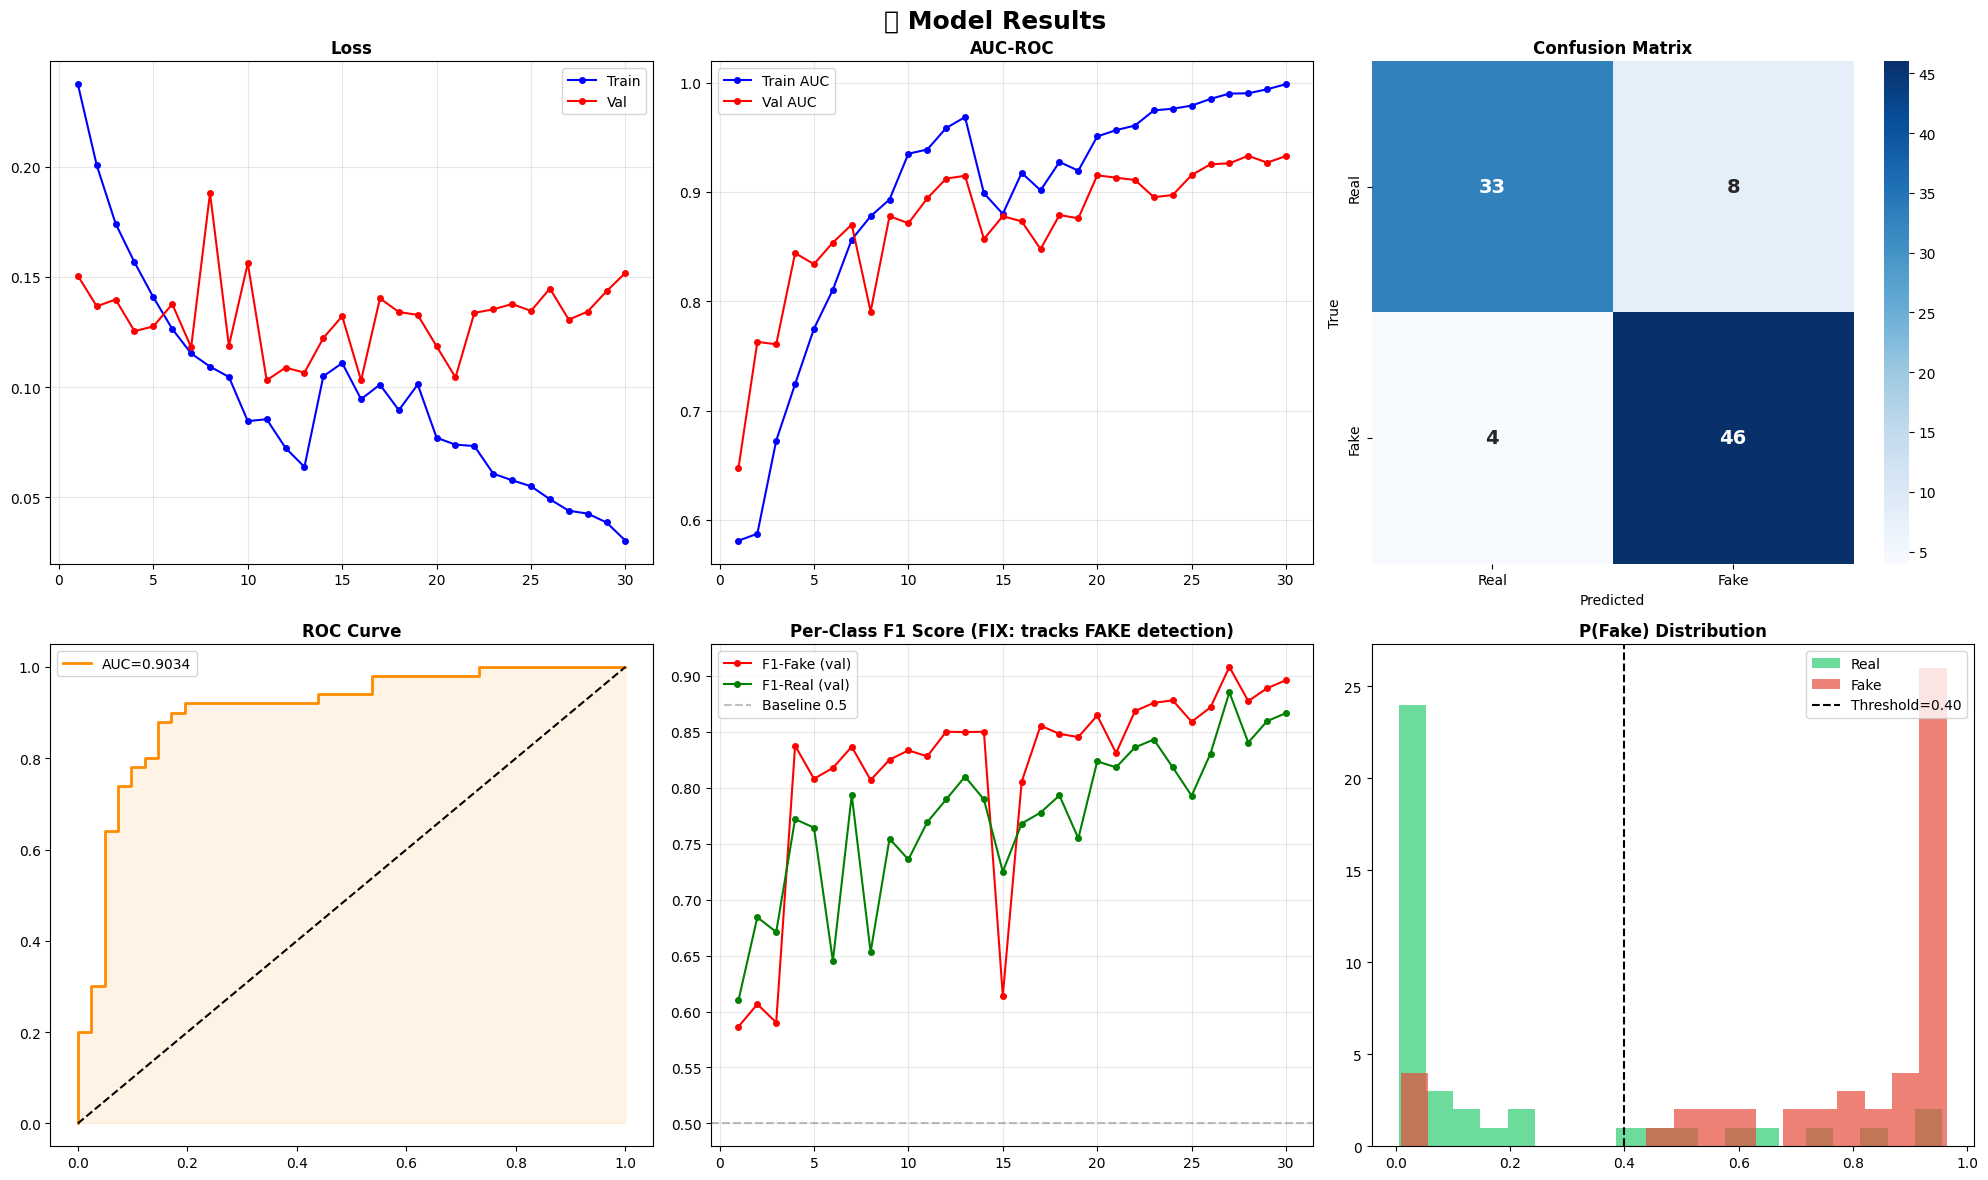

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('📊 Model Results', fontsize=18, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train', markersize=4)
ax.plot(epochs_range, history['val_loss'],   'r-o', label='Val',   markersize=4)
ax.set_title('Loss', fontweight='bold'); ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs_range, history['train_auc'], 'b-o', label='Train AUC', markersize=4)
ax.plot(epochs_range, history['val_auc'],   'r-o', label='Val AUC',   markersize=4)
ax.set_title('AUC-ROC', fontweight='bold'); ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 2]
cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

ax = axes[1, 0]
fpr, tpr, _ = roc_curve(test_metrics['labels'], test_metrics['probs'])
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={test_metrics["auc_roc"]:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1.5)
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_title('ROC Curve', fontweight='bold'); ax.legend()

ax = axes[1, 1]
# FIX F3: Show per-class F1 over training to diagnose class bias
ax.plot(epochs_range, history['val_f1_fake'], 'r-o', label='F1-Fake (val)', markersize=4)
ax.plot(epochs_range, history['val_f1_real'], 'g-o', label='F1-Real (val)', markersize=4)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline 0.5')
ax.set_title('Per-Class F1 Score (FIX: tracks FAKE detection)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 2]
real_mask = test_metrics['labels'] == 0
fake_mask = test_metrics['labels'] == 1
ax.hist(test_metrics['probs'][real_mask], bins=20, alpha=0.7, color='#2ecc71', label='Real')
ax.hist(test_metrics['probs'][fake_mask], bins=20, alpha=0.7, color='#e74c3c', label='Fake')
ax.axvline(optimal_threshold, color='black', linestyle='--', label=f'Threshold={optimal_threshold:.2f}')
ax.set_title('P(Fake) Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{CFG.LOG_DIR}/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

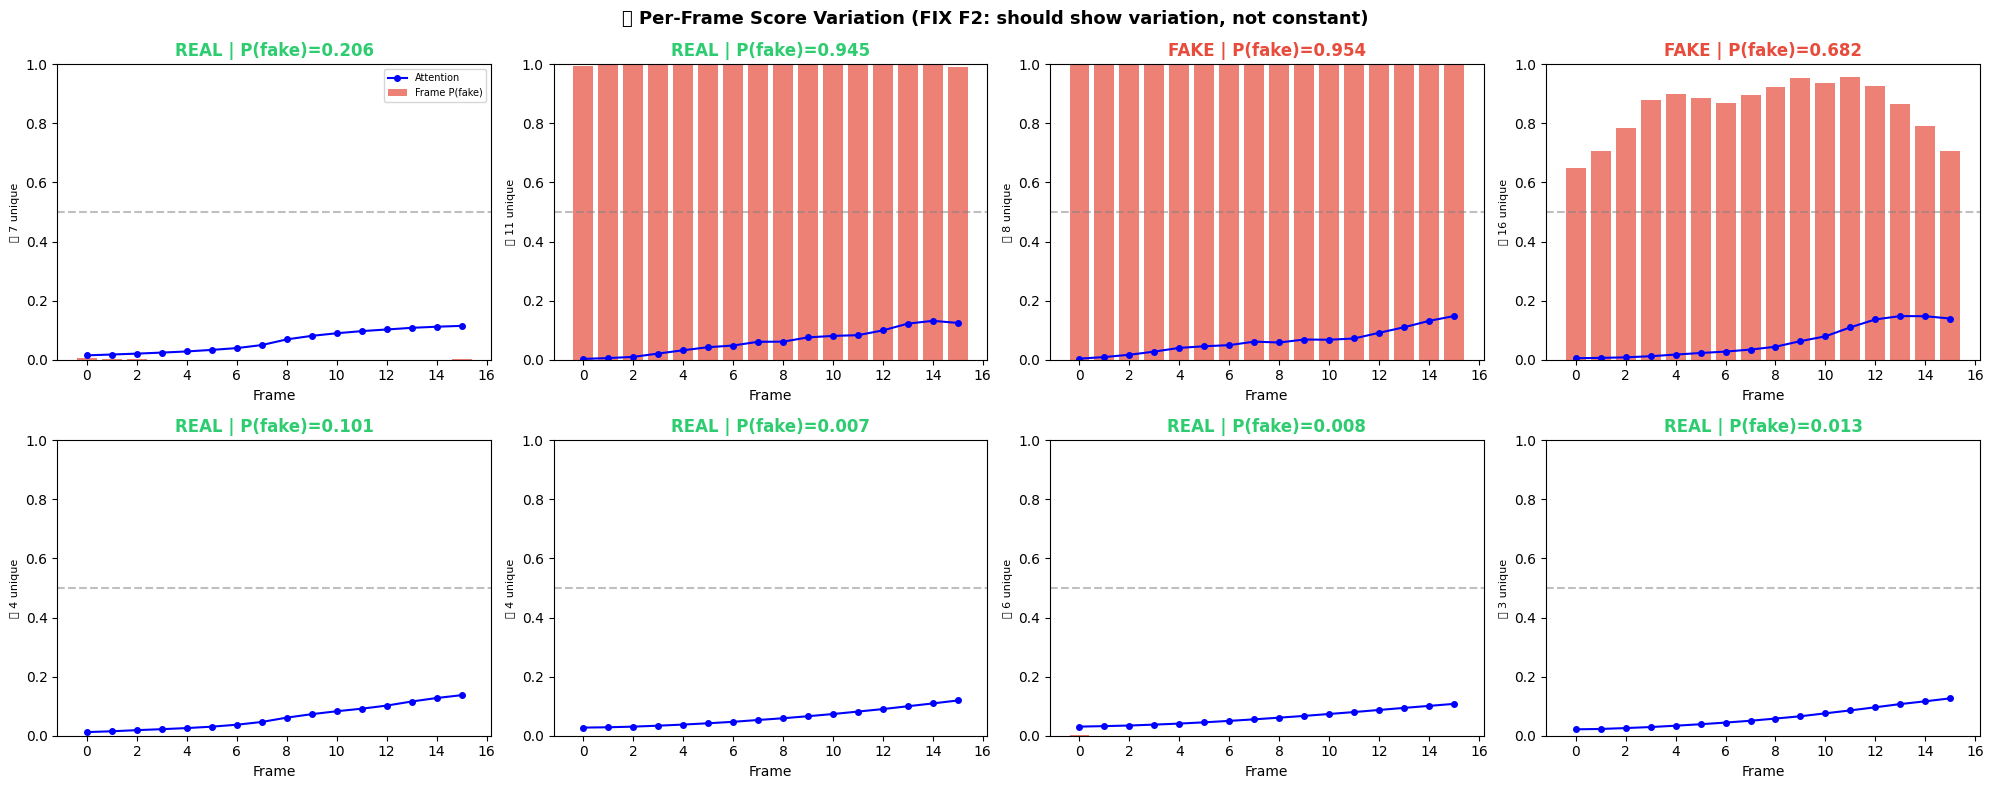

✅ Per-frame score visualization saved


In [23]:
# ── Visualize per-frame score variation (FIX F2 validation) ──────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('📊 Per-Frame Score Variation (FIX F2: should show variation, not constant)',
             fontsize=13, fontweight='bold')

sample_idx = 0
for video_batch, label_batch in test_ds.take(1):
    logit, attn, frame_sc = _wrapper.model(video_batch, training=False)

    for i in range(min(8, int(video_batch.shape[0]))):
        ax      = axes[i // 4][i % 4]
        fs      = frame_sc[i, :, 0].numpy()  # (T,)
        attn_i  = attn[i].numpy()            # (T,)
        label   = int(label_batch[i].numpy())
        p_fake  = float(tf.sigmoid(logit[i][0]).numpy())

        ax.bar(range(CFG.NUM_FRAMES), fs, color='#e74c3c', alpha=0.7, label='Frame P(fake)')
        ax.plot(range(CFG.NUM_FRAMES), attn_i, 'b-o', markersize=4, label='Attention')
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)
        ax.set_title(f'{"FAKE" if label==1 else "REAL"} | P(fake)={p_fake:.3f}',
                     fontweight='bold',
                     color='#e74c3c' if label==1 else '#2ecc71')
        ax.set_xlabel('Frame')

        # Check if scores are varied
        n_unique = len(np.unique(fs.round(4)))
        status   = f'✅ {n_unique} unique' if n_unique > 1 else '❌ CONSTANT'
        ax.set_ylabel(status, fontsize=8)
        if i == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{CFG.LOG_DIR}/per_frame_scores.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Per-frame score visualization saved')

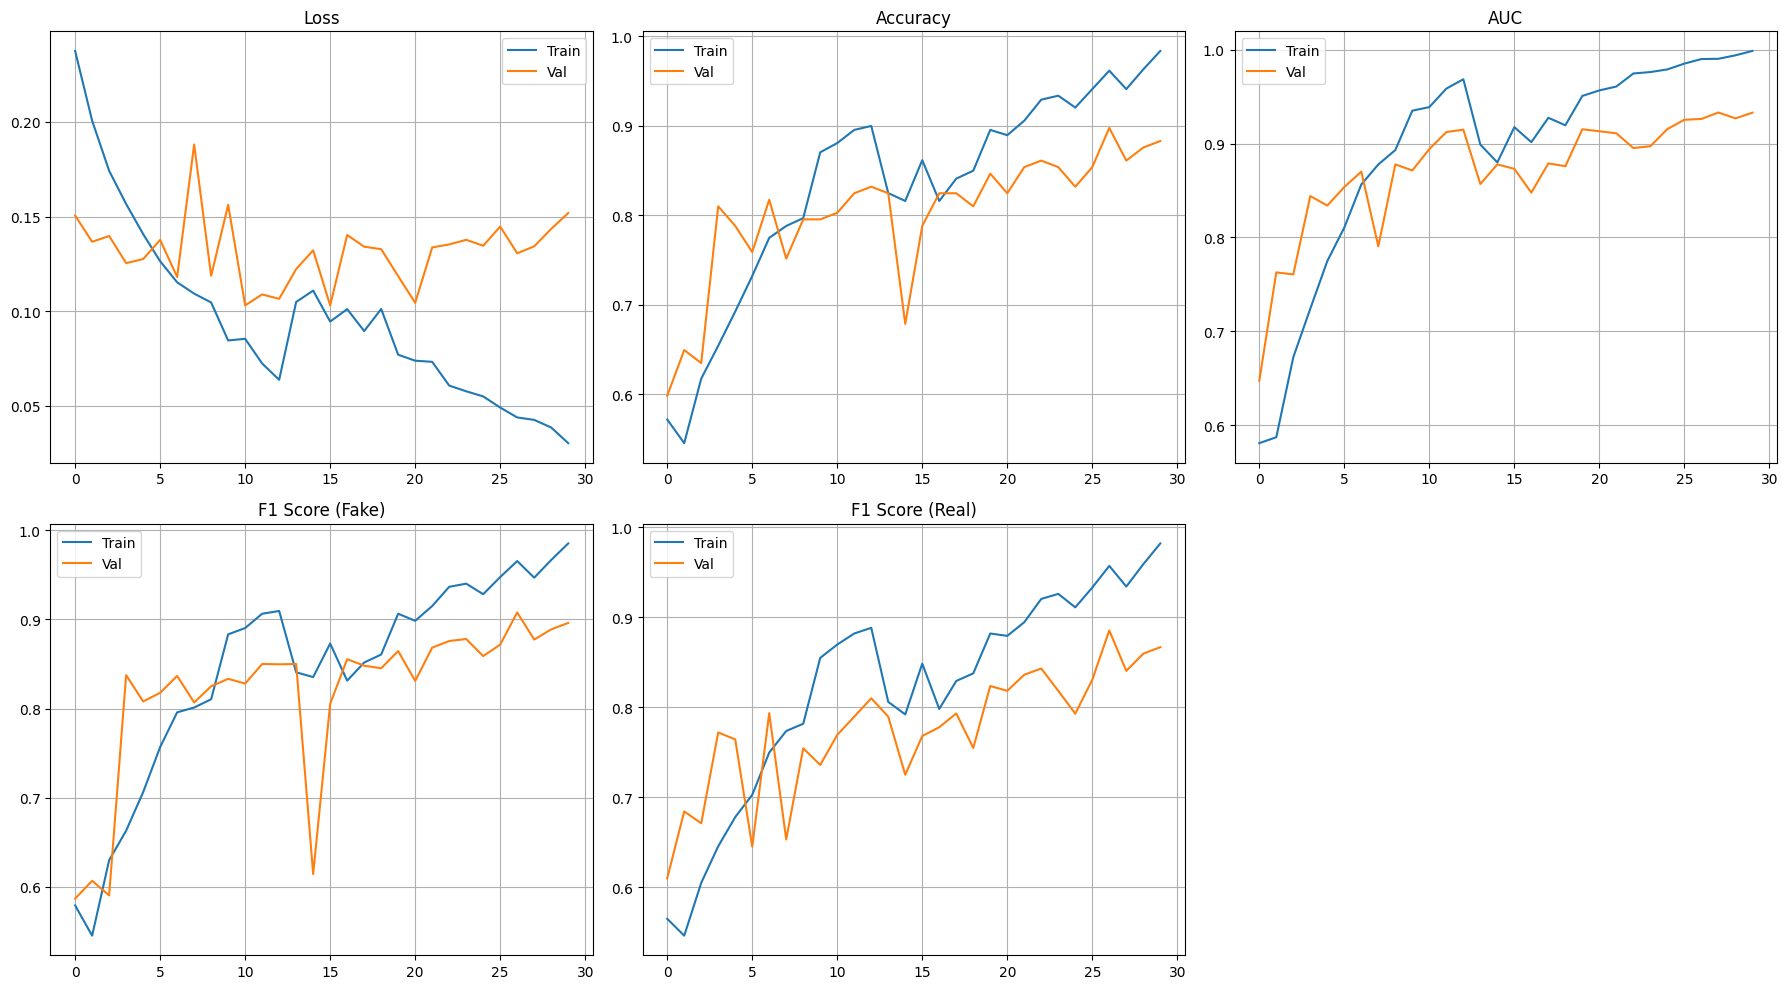

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

# Loss
plt.subplot(2, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid()

# Accuracy
plt.subplot(2, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid()

# AUC
plt.subplot(2, 3, 3)
plt.plot(history['train_auc'], label='Train')
plt.plot(history['val_auc'], label='Val')
plt.title('AUC')
plt.legend()
plt.grid()

# F1 Fake
plt.subplot(2, 3, 4)
plt.plot(history['train_f1_fake'], label='Train')
plt.plot(history['val_f1_fake'], label='Val')
plt.title('F1 Score (Fake)')
plt.legend()
plt.grid()

# F1 Real
plt.subplot(2, 3, 5)
plt.plot(history['train_f1_real'], label='Train')
plt.plot(history['val_f1_real'], label='Val')
plt.title('F1 Score (Real)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_probs, all_labels = [], []

for video_batch, label_batch in val_ds:
    logit, _, _ = model(video_batch, training=False)
    probs = tf.sigmoid(tf.squeeze(logit, axis=-1))

    all_probs.append(probs.numpy())
    all_labels.append(label_batch.numpy())

y_pred_prob = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)
y_pred = (y_pred_prob >= 0.5).astype(int)

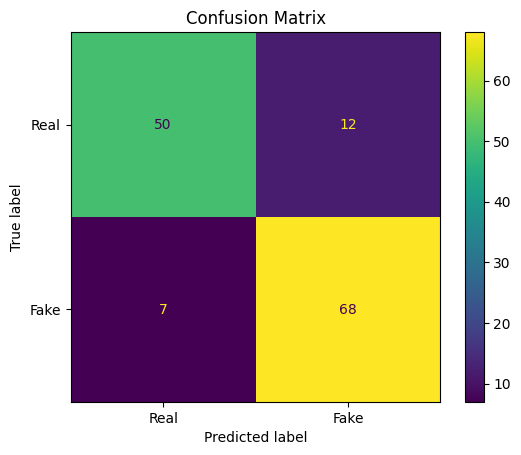

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real','Fake'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [44]:
print(classification_report(y_true, y_pred, target_names=['Real','Fake']))

              precision    recall  f1-score   support

        Real       0.88      0.81      0.84        62
        Fake       0.85      0.91      0.88        75

    accuracy                           0.86       137
   macro avg       0.86      0.86      0.86       137
weighted avg       0.86      0.86      0.86       137



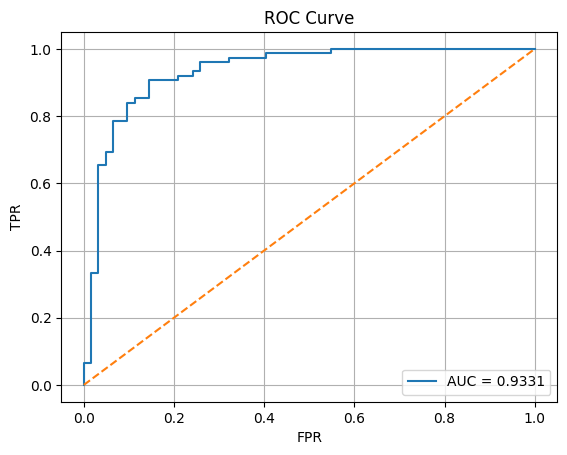

In [45]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

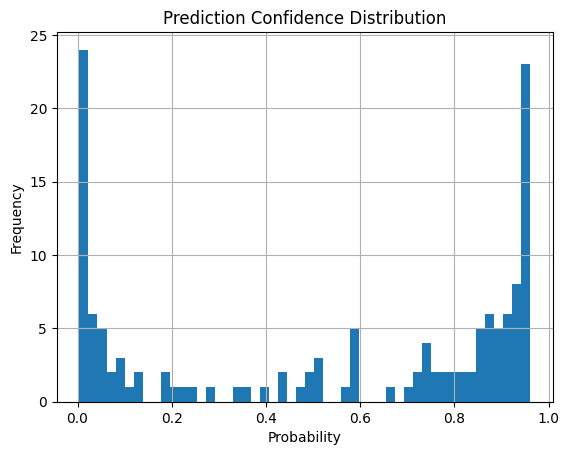

In [46]:
plt.figure()
plt.hist(y_pred_prob, bins=50)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.grid()
plt.show()

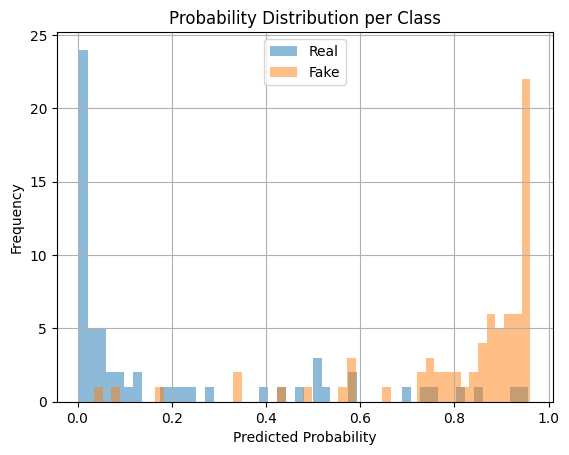

In [47]:
plt.figure()

plt.hist(y_pred_prob[y_true==0], bins=50, alpha=0.5, label='Real')
plt.hist(y_pred_prob[y_true==1], bins=50, alpha=0.5, label='Fake')

plt.legend()
plt.title("Probability Distribution per Class")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid()
plt.show()

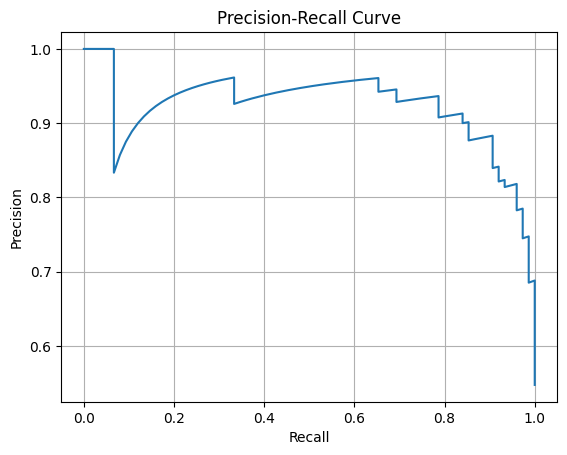

In [49]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

## 15. Save Final Model

In [ ]:
# ── Save as required: videos_model_final.keras ────────────────────────────────
final_path = Path(CFG.MODEL_DIR) / 'videos_model_final.keras'
_wrapper.model.save(str(final_path))
print(f'✅ Model saved: {final_path}')
print(f'   Size: {final_path.stat().st_size / 1e6:.1f} MB')

# ── Save metadata ─────────────────────────────────────────────────────────────
meta = {
    'architecture'     : 'ResNet50 + SE + SpatialAttention + BiLSTM + TemporalAttention',
    'framework'        : f'TensorFlow {tf.__version__} / Keras {keras.__version__}',
    'input_shape'      : [CFG.NUM_FRAMES, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3],
    'outputs'          : {
        '0': 'logit (B,1) — video-level fake logit, apply sigmoid',
        '1': 'attn_weights (B,T) — temporal attention per frame',
        '2': 'frame_scores (B,T,1) — per-frame P(fake), already sigmoid'
    },
    'optimal_threshold': optimal_threshold,
    'label_convention' : '0=real, 1=fake',
    'config': {k: v for k, v in CFG.__dict__.items() if not k.startswith('_')},
    'test_metrics': {k: float(v) for k, v in test_metrics.items() if isinstance(v, float)}
}

with open(Path(CFG.MODEL_DIR) / 'model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'✅ Metadata saved')
print(f'   optimal_threshold={optimal_threshold:.3f}')

# ── Verify reload ──────────────────────────────────────────────────────────────
print('\nVerifying reload...')
reloaded = keras.models.load_model(
    str(final_path),
    custom_objects={
        'SEBlock'          : SEBlock,
        'SpatialAttention' : SpatialAttention,
        'TemporalAttention': TemporalAttention,
        'FocalBCE'         : FocalBCE,
        'LabelSmoothingBCE': LabelSmoothingBCE
    },
    compile=False
)

dummy  = tf.random.normal([2, CFG.NUM_FRAMES, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3])
r_logit, r_attn, r_frames = reloaded(dummy, training=False)
print(f'✅ Reload OK')
print(f'   logit:       {r_logit.shape}   (B, 1)')
print(f'   attn_weights:{r_attn.shape}  (B, T)')
print(f'   frame_scores:{r_frames.shape} (B, T, 1) ← NEW: per-frame predictions')

# Confirm frame scores vary
fs_sample = r_frames[0, :, 0].numpy()
print(f'\n   Frame scores sample: {np.round(fs_sample, 3).tolist()}')
print(f'   Unique scores: {len(np.unique(fs_sample.round(4)))}/{CFG.NUM_FRAMES}')

✅ Model saved: /content/deep-fake-detection/working/models/videos_model_final.keras
   Size: 168.6 MB
✅ Metadata saved
   optimal_threshold=0.400

Verifying reload...
✅ Reload OK
   logit:       (2, 1)   (B, 1)
   attn_weights:(2, 16)  (B, T)
   frame_scores:(2, 16, 1) (B, T, 1) ← NEW: per-frame predictions

   Frame scores sample: [0.006000000052154064, 0.003000000026077032, 0.0020000000949949026, 0.0010000000474974513, 0.0010000000474974513, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0010000000474974513, 0.0010000000474974513, 0.0020000000949949026, 0.003000000026077032]
   Unique scores: 9/16


## 17. Final Summary

In [ ]:
class GradCAM:
    _CANDIDATES = [
        'se_block_layer4',   # SE after ResNet layer4  (2048ch, 7x7) — preferred
        'spatial_attention', # Spatial attention map   (2048ch, 7x7)
        'se_block_layer3',   # SE after ResNet layer3  (1024ch, 14x14)
        'conv5_block3_out',  # Raw ResNet layer4 output (2048ch, 7x7)
        'conv4_block6_out',  # Raw ResNet layer3 output (1024ch, 14x14)
    ]

    def __init__(self, model, target_class=1):
        self.model        = model
        self.target_class = target_class  # FIX 5b: 1=FAKE, 0=REAL
        self.cnn          = model.get_layer('time_distributed_cnn').layer

        target_layer = None
        for name in self._CANDIDATES:
            try:
                lyr = self.cnn.get_layer(name)
                if len(lyr.output.shape) == 4:
                    target_layer = lyr; break
            except (ValueError, AttributeError): continue

        if target_layer is None:
            for lyr in reversed(self.cnn.layers):
                try:
                    if len(lyr.output.shape) == 4:
                        target_layer = lyr; break
                except AttributeError: continue

        if target_layer is None:
            raise RuntimeError(f'No 4-D layer found. CNN layers: {[l.name for l in self.cnn.layers]}')

        self.target_name = target_layer.name
        print(f'[GradCAM] Target layer : {self.target_name}  shape={target_layer.output.shape}')
        print(f'          Target class : {target_class} ({"FAKE" if target_class==1 else "REAL"})')
        self.grad_model = keras.Model(
            inputs  = self.cnn.inputs,
            outputs = [target_layer.output, self.cnn.output],
            name    = 'gradcam_extractor'
        )

    def _forward(self, frame_t):
        with tf.GradientTape() as tape:
            tape.watch(frame_t)

            conv_out, cnn_feat = self.grad_model(frame_t, training=False)
            sign  = 1.0 if self.target_class == 1 else -1.0
            score = sign * tf.reduce_mean(cnn_feat)

        grads = tape.gradient(score, conv_out) 
        return conv_out, grads

    def heatmap(self, frame_norm):
        frame_t = tf.expand_dims(
            tf.constant(frame_norm, dtype=tf.float32), axis=0
        )  # (1, H, W, 3)

        conv_out, grads = self._forward(frame_t)

        if grads is None:
            print(f'[GradCAM] WARNING: grads=None for "{self.target_name}". Using input-gradient saliency.')
            with tf.GradientTape() as tape2:
                tape2.watch(frame_t)
                _, feat2 = self.grad_model(frame_t, training=False)
                sign     = 1.0 if self.target_class == 1 else -1.0
                score2   = sign * tf.reduce_mean(feat2)
            g2 = tape2.gradient(score2, frame_t)
            if g2 is None:
                return np.full((CFG.FRAME_SIZE, CFG.FRAME_SIZE), 0.5, np.float32)
            cam_raw = tf.reduce_max(tf.abs(g2[0]), axis=-1).numpy()
            cam_raw = np.maximum(cam_raw, 0)
            return (cam_raw / (cam_raw.max() + 1e-8)).astype(np.float32)

        # Standard Grad-CAM
        # Step 1: channel weights = global-avg-pool of gradients over spatial dims
        pooled = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()  # (C,)
        maps   = conv_out[0].numpy()                            # (h, w, C)

        # Step 2: weighted sum of feature maps
        cam = np.einsum('c,hwc->hw', pooled, maps)  # (h, w)

        # Step 3: ReLU (only positive influence matters)
        cam = np.maximum(cam, 0)

        # Step 4: normalise to [0, 1]  —  FIX 5d: epsilon guard
        cam_max = cam.max()
        cam = cam / (cam_max + 1e-8) if cam_max > 1e-8 else np.full_like(cam, 0.5, np.float32)

        # Step 5: bilinear upscale to 224x224
        cam_up = np.array(
            Image.fromarray((cam * 255).astype(np.uint8), mode='L')
                 .resize((CFG.FRAME_SIZE, CFG.FRAME_SIZE), Image.BILINEAR),
            dtype=np.float32
        ) / 255.0
        return cam_up   # (H, W) in [0, 1]


def denorm(frame):
    return np.clip(frame * IMAGENET_STD + IMAGENET_MEAN, 0.0, 1.0)


# ── Instantiate ──────────────────────────────────────────────────────────────
print('Building GradCAM engine...')
gradcam = GradCAM(_wrapper.model, target_class=1)

# ── Sanity check: heatmaps must be non-blank and vary per frame (FIX 6) ──────
print('\nRunning GradCAM sanity check...')
_rng = np.random.default_rng(42)
_dummy = _rng.standard_normal((4, CFG.FRAME_SIZE, CFG.FRAME_SIZE, 3)).astype(np.float32)
_hms   = [gradcam.heatmap(_dummy[i]) for i in range(4)]
_blanks = sum(1 for h in _hms if h.max() < 1e-6)
_means  = [round(float(h.mean()), 5) for h in _hms]
_diffs  = [abs(_hms[i].mean() - _hms[j].mean())
           for i in range(len(_hms)) for j in range(i+1, len(_hms))]
print(f'  Blank heatmaps   : {_blanks}/4  '
      f'({"PASS: none blank" if _blanks==0 else "FAIL: blanks — check target layer"})')
print(f'  Per-frame means  : {_means}')
print(f'  Max pairwise diff: {max(_diffs):.5f}  '
      f'({"PASS: frames differ" if max(_diffs)>1e-5 else "FAIL: frames identical"})')
print('\nGradCAM ready')


Building GradCAM engine...
[GradCAM] Target layer : se_block_layer4  shape=(None, 7, 7, 2048)
          Target class : 1 (FAKE)

Running GradCAM sanity check...
  Blank heatmaps   : 0/4  (PASS: none blank)
  Per-frame means  : [0.39381, 0.47005, 0.47194, 0.47866]
  Max pairwise diff: 0.08485  (PASS: frames differ)

GradCAM ready


🔍 Searching for REAL example…
🔍 Searching for FAKE example…

⚙️  Running inference + GradCAM (this takes ~30s on GPU)…


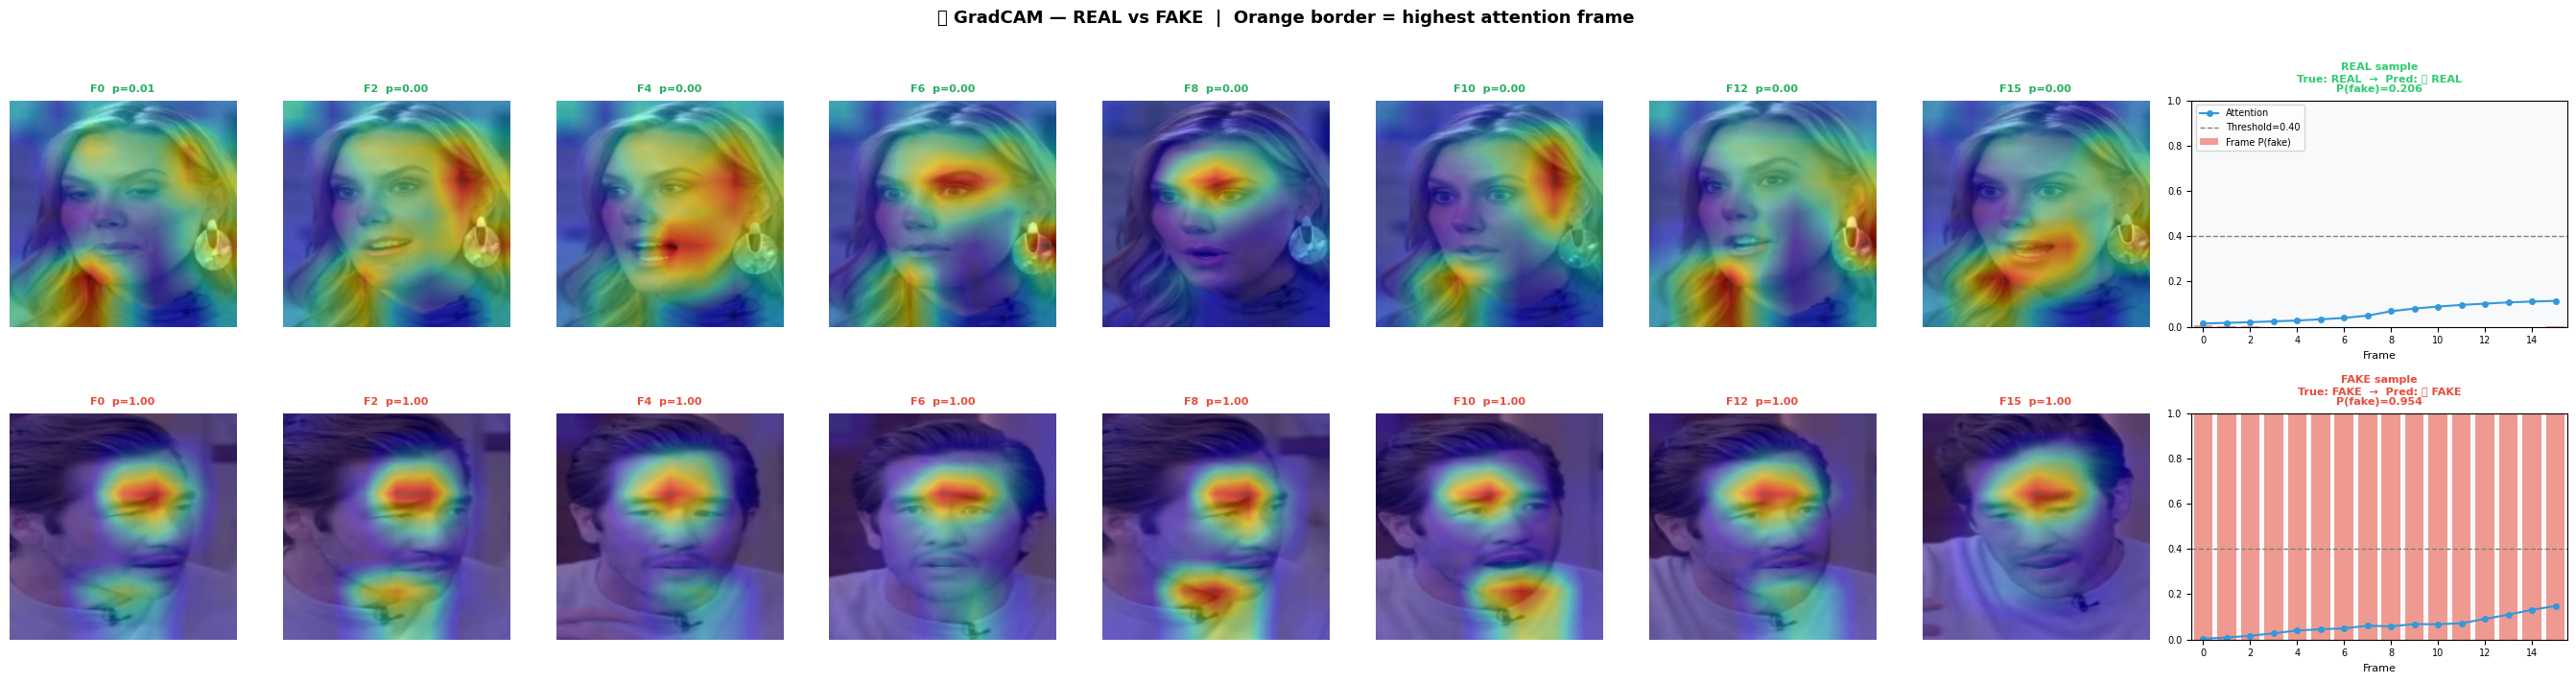

✅ Saved → /content/deep-fake-detection/working/logs/gradcam_real_vs_fake.png

════════════════════════════════════════════════════════════
  REAL sample
    P(fake)          : 0.2064
    Verdict          : REAL  ✅
    Unique frame scores: 4 / 16
    Most attended frame: 15

  FAKE sample
    P(fake)          : 0.9542
    Verdict          : FAKE  ✅
    Unique frame scores: 4 / 16
    Most attended frame: 15
════════════════════════════════════════════════════════════


In [ ]:
def run_example(label_wanted: int, dataset, max_batches: int = 20):
    """
    Pull one sample with label == label_wanted from dataset.
    Returns (video_np, label_int) or raises if not found.
    """
    for video_batch, label_batch in dataset.take(max_batches):
        for i in range(int(video_batch.shape[0])):
            if int(label_batch[i].numpy()) == label_wanted:
                return video_batch[i].numpy(), label_wanted
    raise ValueError(f"No sample with label={label_wanted} found in first {max_batches} batches")


def analyse_sample(video_np: np.ndarray, true_label: int,
                   gradcam_engine: GradCAM, model,
                   n_show: int = 8):
    
    video_t = tf.constant(video_np[np.newaxis], dtype=tf.float32)  # (1, T, H, W, 3)
    logit, attn_w, frame_sc = model(video_t, training=False)

    p_fake      = float(tf.sigmoid(logit[0, 0]).numpy())
    attn_np     = attn_w[0].numpy()                    # (T,)
    frame_np    = frame_sc[0, :, 0].numpy()            # (T,)
    verdict     = 'FAKE' if p_fake >= optimal_threshold else 'REAL'
    correct     = verdict == ('FAKE' if true_label == 1 else 'REAL')

    # Pick frames to show: spread evenly + highest-attention frame
    frame_indices = sorted(set(
        np.linspace(0, CFG.NUM_FRAMES - 1, n_show, dtype=int).tolist() +
        [int(np.argmax(attn_np))]
    ))[:n_show]

    heatmaps = [gradcam_engine.heatmap(video_np[fi]) for fi in frame_indices]

    return {
        'p_fake'       : p_fake,
        'verdict'      : verdict,
        'correct'      : correct,
        'true_label'   : 'FAKE' if true_label == 1 else 'REAL',
        'attn_np'      : attn_np,
        'frame_np'     : frame_np,
        'frame_indices': frame_indices,
        'heatmaps'     : heatmaps,
        'video_np'     : video_np,
    }


def plot_example(res: dict, title_prefix: str, ax_row, show_legend: bool = False):
    
    n_show = len(res['frame_indices'])
    color  = '#e74c3c' if res['true_label'] == 'FAKE' else '#2ecc71'

    for col, (fi, cam) in enumerate(zip(res['frame_indices'], res['heatmaps'])):
        ax = ax_row[col]
        frame_disp = denorm(res['video_np'][fi])

        # Overlay: 50% original + 50% jet heatmap
        heatmap_rgb = plt.cm.jet(cam)[:, :, :3]
        overlay     = np.clip(0.55 * frame_disp + 0.45 * heatmap_rgb, 0, 1)
        ax.imshow(overlay)
        ax.axis('off')

        # Frame-level score badge
        fs = res['frame_np'][fi]
        ax.set_title(
            f'F{fi}  p={fs:.2f}',
            fontsize=8,
            color='#e74c3c' if fs >= 0.5 else '#27ae60',
            fontweight='bold'
        )

        # Highlight the most-attended frame
        if fi == int(np.argmax(res['attn_np'])):
            for spine in ax.spines.values():
                spine.set_edgecolor('#f39c12')
                spine.set_linewidth(3)
                spine.set_visible(True)

    # Last column: temporal chart
    ax_t = ax_row[n_show]
    x    = np.arange(CFG.NUM_FRAMES)
    bars = ax_t.bar(x, res['frame_np'],  color='#e74c3c', alpha=0.55, label='Frame P(fake)')
    ax_t.plot(x, res['attn_np'], 'o-', color='#3498db',  linewidth=1.5,
              markersize=4, label='Attention')
    ax_t.axhline(optimal_threshold, color='gray', linestyle='--', linewidth=1,
                 label=f'Threshold={optimal_threshold:.2f}')
    ax_t.set_xlim(-0.5, CFG.NUM_FRAMES - 0.5)
    ax_t.set_ylim(0, 1)
    ax_t.set_xlabel('Frame', fontsize=8)
    ax_t.tick_params(labelsize=7)
    ax_t.set_facecolor('#f8f9fa')

    verdict_str = f'{"✅" if res["correct"] else "❌"} {res["verdict"]}'
    ax_t.set_title(
        f'{title_prefix}\n'
        f'True: {res["true_label"]}  →  Pred: {verdict_str}\n'
        f'P(fake)={res["p_fake"]:.3f}',
        fontsize=8, fontweight='bold', color=color
    )
    if show_legend:
        ax_t.legend(fontsize=7, loc='upper left')


# ── Pull one REAL and one FAKE sample ────────────────────────────────────────
print('🔍 Searching for REAL example…')
video_real, lbl_real = run_example(label_wanted=0, dataset=test_ds)
print('🔍 Searching for FAKE example…')
video_fake, lbl_fake = run_example(label_wanted=1, dataset=test_ds)

# ── Run analysis ──────────────────────────────────────────────────────────────
print('\n⚙️  Running inference + GradCAM (this takes ~30s on GPU)…')
N_SHOW = 8   # frames per row (must be ≤ NUM_FRAMES)

res_real = analyse_sample(video_real, lbl_real, gradcam, _wrapper.model, n_show=N_SHOW)
res_fake = analyse_sample(video_fake, lbl_fake, gradcam, _wrapper.model, n_show=N_SHOW)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, N_SHOW + 1,
    figsize=((N_SHOW + 1) * 3, 7),
    gridspec_kw={'width_ratios': [1] * N_SHOW + [1.6]}
)
fig.suptitle(
    '🔬 GradCAM — REAL vs FAKE  |  Orange border = highest attention frame',
    fontsize=13, fontweight='bold', y=1.01
)

plot_example(res_real, 'REAL sample', axes[0], show_legend=True)
plot_example(res_fake, 'FAKE sample', axes[1], show_legend=False)

plt.tight_layout()
out_path = f'{CFG.LOG_DIR}/gradcam_real_vs_fake.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {out_path}')

# ── Text summary ──────────────────────────────────────────────────────────────
print('\n' + '═' * 60)
print('  REAL sample')
print(f'    P(fake)          : {res_real["p_fake"]:.4f}')
print(f'    Verdict          : {res_real["verdict"]}  {"✅" if res_real["correct"] else "❌"}')
print(f'    Unique frame scores: {len(np.unique(res_real["frame_np"].round(3)))} / {CFG.NUM_FRAMES}')
print(f'    Most attended frame: {int(np.argmax(res_real["attn_np"]))}')
print()
print('  FAKE sample')
print(f'    P(fake)          : {res_fake["p_fake"]:.4f}')
print(f'    Verdict          : {res_fake["verdict"]}  {"✅" if res_fake["correct"] else "❌"}')
print(f'    Unique frame scores: {len(np.unique(res_fake["frame_np"].round(3)))} / {CFG.NUM_FRAMES}')
print(f'    Most attended frame: {int(np.argmax(res_fake["attn_np"]))}')
print('═' * 60)

In [50]:
print('=' * 70)
print('   🎬 DEEPFAKE DETECTION - MODEL SUMMARY')
print('=' * 70)
print(f'  Framework        : TensorFlow {tf.__version__} / Keras {keras.__version__}')
print(f'  Architecture     : ResNet-50 + SE + SpatialAttn + BiLSTM + TemporalAttn')
print(f'  Input            : {CFG.NUM_FRAMES} frames × {CFG.FRAME_SIZE}×{CFG.FRAME_SIZE}')
print(f'  Parameters       : {_wrapper.model.count_params():,}')
print()
print('  Outputs:')
print(f'    [0] logit        : (B, 1)    video-level fake score')
print(f'    [1] attn_weights : (B, {CFG.NUM_FRAMES})   temporal attention per frame')
print(f'    [2] frame_scores : (B, {CFG.NUM_FRAMES}, 1) per-frame P(fake) ← FIXED')
print()
print('  Test Metrics:')
for k in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']:
    print(f'    {k:<22}: {test_metrics[k]:.4f}')
print(f'    {"optimal_threshold":<22}: {optimal_threshold:.4f}')

   🎬 DEEPFAKE DETECTION - MODEL SUMMARY
  Framework        : TensorFlow 2.19.0 / Keras 3.13.2
  Architecture     : ResNet-50 + SE + SpatialAttn + BiLSTM + TemporalAttn
  Input            : 16 frames × 224×224
  Parameters       : 41,966,180

  Outputs:
    [0] logit        : (B, 1)    video-level fake score
    [1] attn_weights : (B, 16)   temporal attention per frame
    [2] frame_scores : (B, 16, 1) per-frame P(fake) ← FIXED

  Test Metrics:
    accuracy              : 0.8681
    precision             : 0.8519
    recall                : 0.9200
    f1                    : 0.8846
    auc_roc               : 0.9034
    optimal_threshold     : 0.4000
